In [6]:
# 1. Imports og grunnoppsett

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import pandas as pd  # til tabeller

print("TensorFlow:", tf.__version__)

# Paths (tilpasset ditt oppsett)
train_path = Path('seg_train/seg_train')
test_path  = Path('seg_test/seg_test')

# Konstanter (samme som i Intel-arbeidet)
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 64
EPOCHS = 150  # kun én hyperparam-kombinasjon



TensorFlow: 2.20.0


In [7]:
# 2. Sjekk og skriv ut GPU-informasjon

print("\n=== Enheter som TensorFlow ser ===")
devices = tf.config.list_physical_devices()
for d in devices:
    print("-", d)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU funnet! Liste over GPU-er:")
    for gpu in gpus:
        try:
            details = tf.config.experimental.get_device_details(gpu)
            gpu_name = details.get('device_name', 'ukjent navn')
        except Exception:
            gpu_name = "ukjent navn (kunne ikke hente detaljer)"
        print(f"- {gpu.name}  |  {gpu_name}")
else:
    print("\nIngen GPU funnet – TensorFlow kjører på CPU.")



=== Enheter som TensorFlow ser ===
- PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU funnet! Liste over GPU-er:
- /physical_device:GPU:0  |  NVIDIA GeForce RTX 2080


In [8]:
# 3. load_data: les inn seg_train/seg_train og seg_test/seg_test

def load_data():
    """
    Load the data:
        - 14,034 images to train the network.
        - 3,000 images to evaluate how accurately the network learned to classify images.
      (tallene gjelder original-datasettet på Kaggle)
    """
    datasets = [str(train_path), str(test_path)]
    output = []

    for dataset in datasets:
        images = []
        labels = []

        print(f"Loading {dataset}")

        # hver subfolder = én klasse
        for folder in os.listdir(dataset):
            # hopp over ting som ikke er en av klassene (bare i tilfelle)
            if folder not in class_names_label:
                print(f"  Advarsel: mapper '{folder}' er ikke i class_names, hopper over.")
                continue

            label = class_names_label[folder]
            folder_path = os.path.join(dataset, folder)

            for file in tqdm(os.listdir(folder_path), desc=f"  {folder}", unit="img"):
                img_path = os.path.join(folder_path, file)

                # les og preprocess bilde
                image = cv2.imread(img_path)
                if image is None:
                    # korrupt fil / annet format
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype='float32')
        labels = np.array(labels, dtype='int32')

        output.append((images, labels))

    return output

(train_images, train_labels), (test_images, test_labels) = load_data()

# shuffle treningsdata (som i originalen)
train_images, train_labels = shuffle(train_images, train_labels, random_state=1)

print("\nShapes:")
print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)


Loading seg_train/seg_train


  street: 100%|██████████| 2382/2382 [00:30<00:00, 79.24img/s]


Loading seg_test/seg_test


  street: 100%|██████████| 501/501 [00:06<00:00, 77.93img/s]



Shapes:
train_images: (14034, 150, 150, 3)
train_labels: (14034,)
test_images: (3000, 150, 150, 3)
test_labels: (3000,)


In [9]:
# 4. Normaliser pikselverdier til [0, 1]

train_images = train_images / 255.0
test_images  = test_images / 255.0

# Antall samples
n_train = train_labels.shape[0]
n_test  = test_labels.shape[0]

print(f"\nAntall treningsbilder: {n_train}")
print(f"Antall testbilder:     {n_test}")
print(f"Bildestørrelse:        {IMAGE_SIZE} x 3 (RGB)")

# --- Tabell: overordnet datasammendrag ---
summary_df = pd.DataFrame(
    {
        "split": ["train", "test"],
        "num_samples": [n_train, n_test],
        "img_height": [IMAGE_SIZE[0], IMAGE_SIZE[0]],
        "img_width": [IMAGE_SIZE[1], IMAGE_SIZE[1]],
        "num_channels": [3, 3],
    }
)
display(summary_df.style.set_caption("Datasammendrag"))



Antall treningsbilder: 14034
Antall testbilder:     3000
Bildestørrelse:        (150, 150) x 3 (RGB)


,split,num_samples,img_height,img_width,num_channels
0,train,14034,150,150,3
1,test,3000,150,150,3


In [10]:
# 4b. Class-fordeling per split (tabeller)

def class_distribution(labels, split_name):
    unique, counts = np.unique(labels, return_counts=True)
    idx_to_name = {v: k for k, v in class_names_label.items()}
    data = {
        "class_index": unique,
        "class_name": [idx_to_name[i] for i in unique],
        "count": counts,
        "fraction": counts / counts.sum(),
    }
    df = pd.DataFrame(data)
    df = df.sort_values("class_index").reset_index(drop=True)
    df["split"] = split_name
    return df

train_dist = class_distribution(train_labels, "train")
test_dist  = class_distribution(test_labels, "test")

display(train_dist.style.set_caption("Class-fordeling – Train"))
display(test_dist.style.set_caption("Class-fordeling – Test"))


,class_index,class_name,count,fraction,split
0,0,mountain,2512,0.178994,train
1,1,street,2382,0.169731,train
2,2,glacier,2404,0.171298,train
3,3,buildings,2191,0.156121,train
4,4,sea,2274,0.162035,train
5,5,forest,2271,0.161821,train


,class_index,class_name,count,fraction,split
0,0,mountain,525,0.175000,test
1,1,street,501,0.167000,test
2,2,glacier,553,0.184333,test
3,3,buildings,437,0.145667,test
4,4,sea,510,0.170000,test
5,5,forest,474,0.158000,test


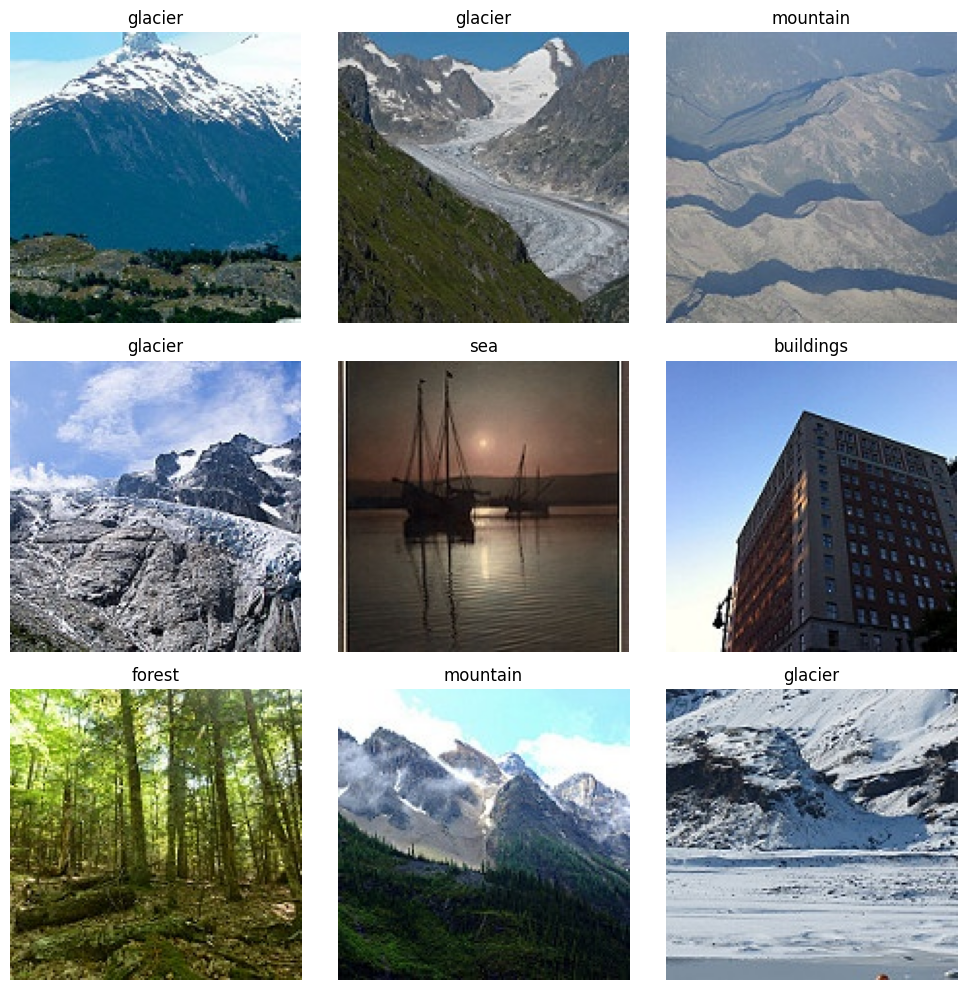

In [11]:
# 5. Plot noen tilfeldige treningsbilder med labels

def show_random_examples(images, labels, class_names, n=9):
    indices = np.random.choice(len(images), size=n, replace=False)

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[idx])
        plt.title(class_names[labels[idx]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_random_examples(train_images, train_labels, class_names, n=9)


TensorFlow: 2.20.0

=== Enheter som TensorFlow ser ===
- PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU funnet! Liste over GPU-er:
- /physical_device:GPU:0  |  NVIDIA GeForce RTX 2080

Loading seg_train/seg_train


  street: 100%|██████████| 2382/2382 [00:12<00:00, 187.97img/s]



Loading seg_test/seg_test


  street: 100%|██████████| 501/501 [00:02<00:00, 194.26img/s]



Shapes:
train_images: (14034, 128, 128, 3)
train_labels: (14034,)
test_images: (3000, 128, 128, 3)
test_labels: (3000,)

Antall treningsbilder: 14034
Antall testbilder:     3000
Bildestørrelse:        (128, 128) x 3 (RGB)


,split,num_samples,img_height,img_width,num_channels
0,train,14034,128,128,3
1,test,3000,128,128,3


,class_index,class_name,count,fraction,split
0,0,mountain,2512,0.178994,train
1,1,street,2382,0.169731,train
2,2,glacier,2404,0.171298,train
3,3,buildings,2191,0.156121,train
4,4,sea,2274,0.162035,train
5,5,forest,2271,0.161821,train


,class_index,class_name,count,fraction,split
0,0,mountain,525,0.175000,test
1,1,street,501,0.167000,test
2,2,glacier,553,0.184333,test
3,3,buildings,437,0.145667,test
4,4,sea,510,0.170000,test
5,5,forest,474,0.158000,test


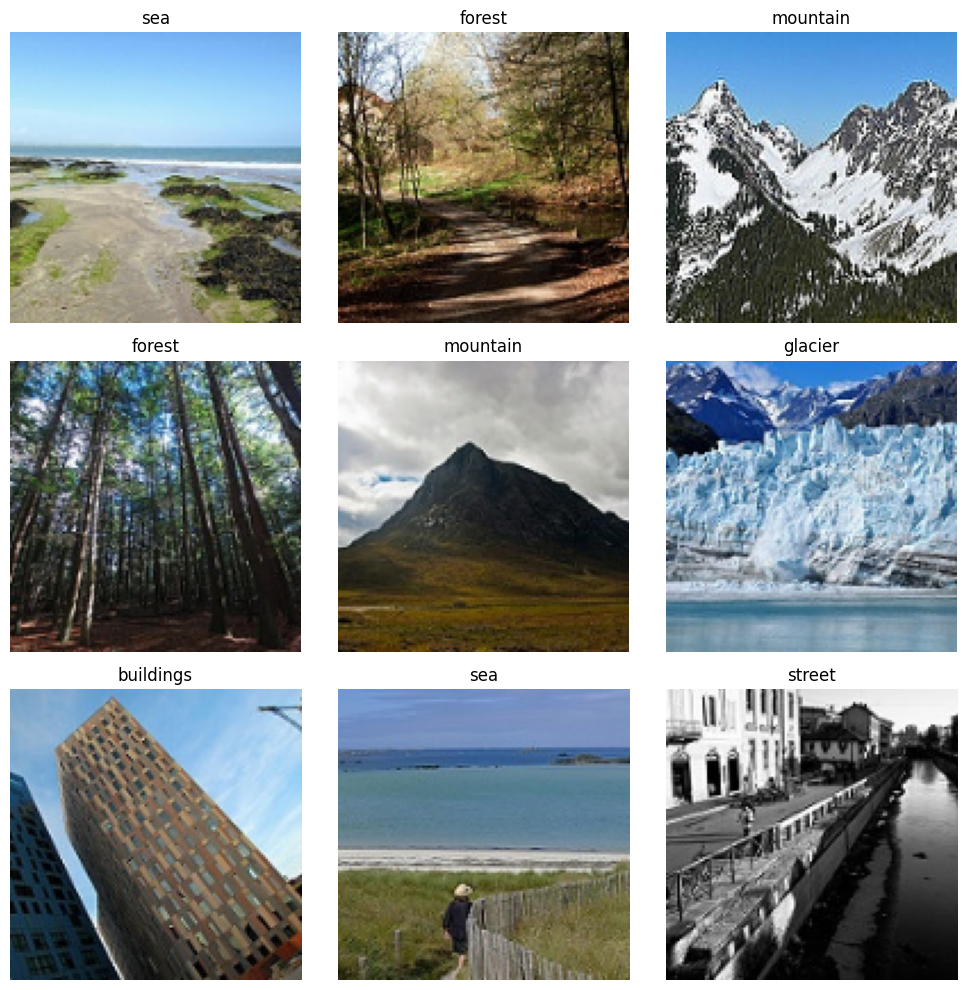

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 124, 124, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,710 (1.64 MB)

 Trainable params: 430,486 (1.64 MB)

 Non-trainable params: 224 (896.00 B)

2025-12-05 15:57:07.194214: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2207318016 exceeds 10% of free system memory.
2025-12-05 15:57:08.860601: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2207318016 exceeds 10% of free system memory.


Epoch 1/30


2025-12-05 15:57:12.069696: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e91a4007100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-05 15:57:12.069725: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2080, Compute Capability 7.5
2025-12-05 15:57:12.128741: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-05 15:57:12.427681: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-12-05 15:57:12.951279: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,124,124]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,128,128]{3,2,1,0}, f32[64,3,5,5]{3,2,1,0}, f32[64]{0}), window={size=5x5}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

702/702 - 19s - 27ms/step - accuracy: 0.5417 - loss: 1.3962 - val_accuracy: 0.6145 - val_loss: 0.9703 - learning_rate: 1.0000e-03
Epoch 2/30
702/702 - 8s - 12ms/step - accuracy: 0.6516 - loss: 0.9379 - val_accuracy: 0.5942 - val_loss: 1.1155 - learning_rate: 1.0000e-03
Epoch 3/30
702/702 - 7s - 10ms/step - accuracy: 0.7092 - loss: 0.8031 - val_accuracy: 0.6416 - val_loss: 0.9709 - learning_rate: 1.0000e-03
Epoch 4/30
702/702 - 7s - 10ms/step - accuracy: 0.7449 - loss: 0.7104 - val_accuracy: 0.4428 - val_loss: 2.1903 - learning_rate: 1.0000e-03
Epoch 5/30
702/702 - 7s - 10ms/step - accuracy: 0.7678 - loss: 0.6450 - val_accuracy: 0.7403 - val_loss: 0.7110 - learning_rate: 1.0000e-03
Epoch 6/30
702/702 - 7s - 10ms/step - accuracy: 0.7927 - loss: 0.5724 - val_accuracy: 0.6975 - val_loss: 0.8068 - learning_rate: 1.0000e-03
Epoch 7/30
702/702 - 8s - 12ms/step - accuracy: 0.8148 - loss: 0.5123 - val_accuracy: 0.7763 - val_loss: 0.6109 - learning_rate: 1.0000e-03
Epoch 8/30
702/702 - 7s - 10ms

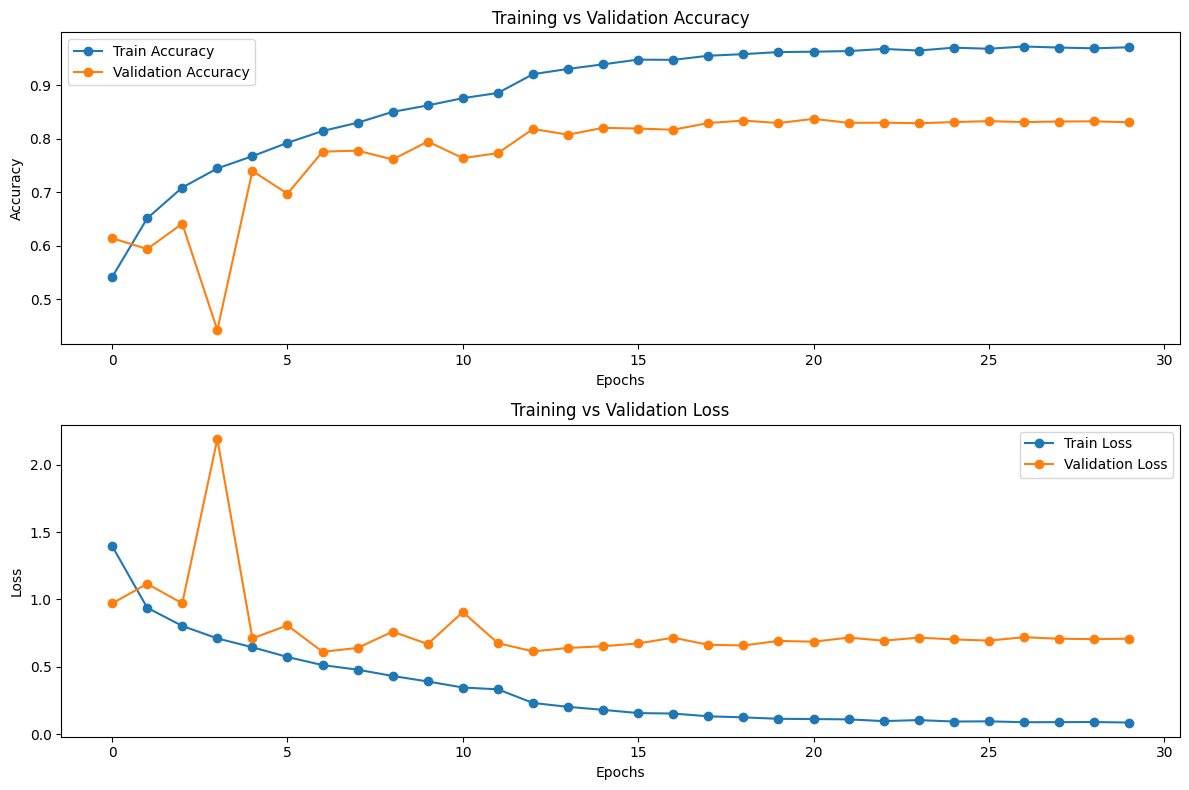

2025-12-05 16:00:59.604149: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,124,124]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,128,128]{3,2,1,0}, f32[64,3,5,5]{3,2,1,0}, f32[64]{0}), window={size=5x5}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-05 16:00:59.762967: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,60,60]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,62,62]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivatio

89/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8167 - loss: 0.7976

2025-12-05 16:01:00.911709: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[24,64,124,124]{3,2,1,0}, u8[0]{0}) custom-call(f32[24,3,128,128]{3,2,1,0}, f32[64,3,5,5]{3,2,1,0}, f32[64]{0}), window={size=5x5}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2025-12-05 16:01:00.984435: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[24,32,60,60]{3,2,1,0}, u8[0]{0}) custom-call(f32[24,64,62,62]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivatio

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8243 - loss: 0.7131

Test loss: 0.7131
Test accuracy: 0.8243


In [ ]:
# 1. Imports og grunnoppsett

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import pandas as pd  # til tabeller

print("TensorFlow:", tf.__version__)

# Paths (tilpasset ditt oppsett)
train_path = Path('seg_train/seg_train')
test_path  = Path('seg_test/seg_test')

# Klasser i Intel-datasettet
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}

# Litt snillere hyperparametere for å unngå OOM
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 30

# 2. Sjekk og skriv ut GPU-informasjon

print("\n=== Enheter som TensorFlow ser ===")
devices = tf.config.list_physical_devices()
for d in devices:
    print("-", d)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU funnet! Liste over GPU-er:")
    for gpu in gpus:
        try:
            details = tf.config.experimental.get_device_details(gpu)
            gpu_name = details.get('device_name', 'ukjent navn')
        except Exception:
            gpu_name = "ukjent navn (kunne ikke hente detaljer)"
        print(f"- {gpu.name}  |  {gpu_name}")
else:
    print("\nIngen GPU funnet – TensorFlow kjører på CPU.")


# 3. load_data: les inn seg_train/seg_train og seg_test/seg_test

def load_data():
    """
    Leser inn trenings- og testbilder fra mapper:
        train_path = seg_train/seg_train
        test_path  = seg_test/seg_test

    Forventer under-mapper med navn lik class_names.
    """
    datasets = [str(train_path), str(test_path)]
    output = []

    for dataset in datasets:
        images = []
        labels = []

        print(f"\nLoading {dataset}")

        # hver subfolder = én klasse
        for folder in os.listdir(dataset):
            # hopp over ting som ikke er en av klassene (bare i tilfelle)
            if folder not in class_names_label:
                print(f"  Advarsel: mappe '{folder}' er ikke i class_names, hopper over.")
                continue

            label = class_names_label[folder]
            folder_path = os.path.join(dataset, folder)

            for file in tqdm(os.listdir(folder_path), desc=f"  {folder}", unit="img"):
                img_path = os.path.join(folder_path, file)

                # les og preprocess bilde
                image = cv2.imread(img_path)
                if image is None:
                    # korrupt fil / annet format
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype='float32')
        labels = np.array(labels, dtype='int32')

        output.append((images, labels))

    return output


# Les inn data
(train_images, train_labels), (test_images, test_labels) = load_data()

# shuffle treningsdata
train_images, train_labels = shuffle(train_images, train_labels, random_state=1)

print("\nShapes:")
print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)

# 4. Normaliser pikselverdier til [0, 1]

train_images = train_images / 255.0
test_images  = test_images / 255.0

# Antall samples
n_train = train_labels.shape[0]
n_test  = test_labels.shape[0]

print(f"\nAntall treningsbilder: {n_train}")
print(f"Antall testbilder:     {n_test}")
print(f"Bildestørrelse:        {IMAGE_SIZE} x 3 (RGB)")

# --- Tabell: overordnet datasammendrag ---
summary_df = pd.DataFrame(
    {
        "split": ["train", "test"],
        "num_samples": [n_train, n_test],
        "img_height": [IMAGE_SIZE[0], IMAGE_SIZE[0]],
        "img_width": [IMAGE_SIZE[1], IMAGE_SIZE[1]],
        "num_channels": [3, 3],
    }
)
try:
    display(summary_df.style.set_caption("Datasammendrag"))
except NameError:
    print(summary_df)


# 4b. Class-fordeling per split (tabeller)

def class_distribution(labels, split_name):
    unique, counts = np.unique(labels, return_counts=True)
    idx_to_name = {v: k for k, v in class_names_label.items()}
    data = {
        "class_index": unique,
        "class_name": [idx_to_name[i] for i in unique],
        "count": counts,
        "fraction": counts / counts.sum(),
    }
    df = pd.DataFrame(data)
    df = df.sort_values("class_index").reset_index(drop=True)
    df["split"] = split_name
    return df


train_dist = class_distribution(train_labels, "train")
test_dist  = class_distribution(test_labels, "test")

try:
    display(train_dist.style.set_caption("Class-fordeling – Train"))
    display(test_dist.style.set_caption("Class-fordeling – Test"))
except NameError:
    print(train_dist)
    print(test_dist)


# 5. Plot noen tilfeldige treningsbilder med labels

def show_random_examples(images, labels, class_names, n=9):
    indices = np.random.choice(len(images), size=n, replace=False)

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[idx])
        plt.title(class_names[labels[idx]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_random_examples(train_images, train_labels, class_names, n=9)


# 6. Definer en litt mindre CNN-modell (for mindre minnebruk)

def create_model():
    
    model = models.Sequential([
        # 1. Conv-blokk
        layers.Conv2D(
            filters=64,                     # mindre enn 128
            kernel_size=(5, 5),
            padding='valid',
            activation='relu',
            input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.BatchNormalization(),

        # 2. Conv-blokk
        layers.Conv2D(
            filters=32,                     # mindre enn 64
            kernel_size=(3, 3),
            padding='valid',
            kernel_regularizer=keras.regularizers.l2(0.00005),
            activation='relu'
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.BatchNormalization(),

        # 3. Conv-blokk
        layers.Conv2D(
            filters=16,                     # mindre enn 32
            kernel_size=(3, 3),
            padding='valid',
            kernel_regularizer=keras.regularizers.l2(0.00005),
            activation='relu'
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.BatchNormalization(),

        # Flatten + dense-lag
        layers.Flatten(),
        layers.Dense(128, activation='relu'),   # mindre enn 256
        layers.Dropout(0.5),

        # Output-lag: én node per klasse
        layers.Dense(len(class_names), activation='softmax')
    ])
    return model


cnn_model = create_model()
cnn_model.summary()


# 7. Kompiler og tren modellen

optimizer = keras.optimizers.Adam(learning_rate=0.001)
lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=np.sqrt(0.1),
    patience=5,
    verbose=1
)

# labelene dine er heltall 0–5 → bruk SparseCategoricalCrossentropy
loss_fn = keras.losses.SparseCategoricalCrossentropy()

cnn_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

history = cnn_model.fit(
    train_images,
    train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # 20 % av train brukes som validation
    verbose=2,
    callbacks=[lr_callback]
)


# 8. Plot trenings- og valideringskurver

train_accuracy = history.history['accuracy']
val_accuracy   = history.history['val_accuracy']
train_loss     = history.history['loss']
val_loss       = history.history['val_loss']

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

ax[0].set_title('Training vs Validation Accuracy')
ax[0].plot(train_accuracy, 'o-', label='Train Accuracy')
ax[0].plot(val_accuracy, 'o-', label='Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='best')

ax[1].set_title('Training vs Validation Loss')
ax[1].plot(train_loss, 'o-', label='Train Loss')
ax[1].plot(val_loss, 'o-', label='Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()


# 9. Evaluer på testsettet

test_loss, test_acc = cnn_model.evaluate(test_images, test_labels, verbose=1)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


2025-12-06 15:09:18.294587: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0

=== Enheter som TensorFlow ser ===
- PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU funnet! Liste over GPU-er:
- /physical_device:GPU:0  |  NVIDIA GeForce RTX 2080

Loading seg_train/seg_train


  street: 100%|██████████| 2382/2382 [00:30<00:00, 77.42img/s]



Loading seg_test/seg_test


  street: 100%|██████████| 501/501 [00:06<00:00, 75.02img/s]



Shapes:
train_images: (14034, 128, 128, 3)
train_labels: (14034,)
test_images: (3000, 128, 128, 3)
test_labels: (3000,)

Antall treningsbilder: 14034
Antall testbilder:     3000
Bildestørrelse:        (128, 128) x 3 (RGB)


,split,num_samples,img_height,img_width,num_channels
0,train,14034,128,128,3
1,test,3000,128,128,3


,class_index,class_name,count,fraction,split
0,0,mountain,2512,0.178994,train
1,1,street,2382,0.169731,train
2,2,glacier,2404,0.171298,train
3,3,buildings,2191,0.156121,train
4,4,sea,2274,0.162035,train
5,5,forest,2271,0.161821,train


,class_index,class_name,count,fraction,split
0,0,mountain,525,0.175000,test
1,1,street,501,0.167000,test
2,2,glacier,553,0.184333,test
3,3,buildings,437,0.145667,test
4,4,sea,510,0.170000,test
5,5,forest,474,0.158000,test


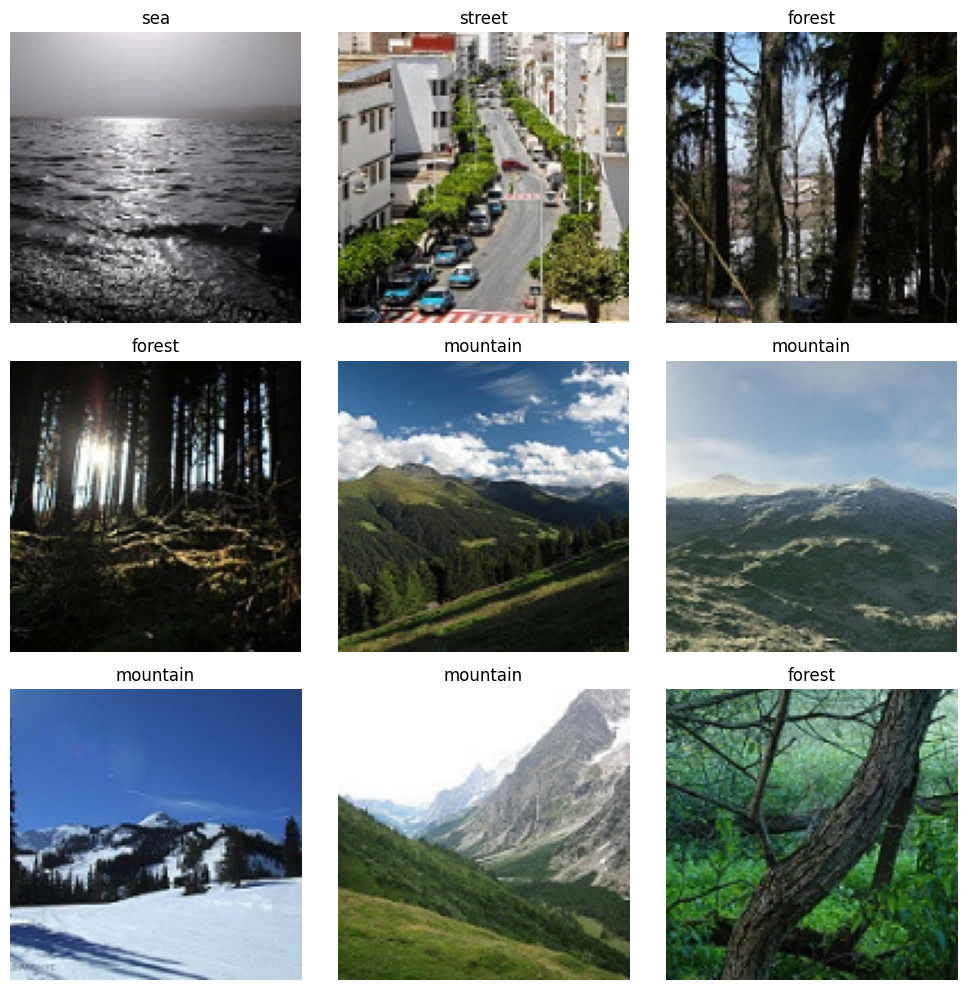

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1765030384.559907    1123 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6063 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 124, 124, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,710 (1.64 MB)

 Trainable params: 430,486 (1.64 MB)

 Non-trainable params: 224 (896.00 B)

2025-12-06 15:13:06.556657: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2207318016 exceeds 10% of free system memory.
2025-12-06 15:13:09.641800: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2207318016 exceeds 10% of free system memory.


Epoch 1/250


2025-12-06 15:13:14.901707: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


702/702 - 31s - 45ms/step - accuracy: 0.4954 - loss: 1.6129 - val_accuracy: 0.4442 - val_loss: 1.7575 - learning_rate: 1.0000e-03
Epoch 2/250
702/702 - 23s - 33ms/step - accuracy: 0.5859 - loss: 1.1235 - val_accuracy: 0.6487 - val_loss: 0.9400 - learning_rate: 1.0000e-03
Epoch 3/250
702/702 - 21s - 30ms/step - accuracy: 0.6084 - loss: 1.0464 - val_accuracy: 0.6338 - val_loss: 0.9125 - learning_rate: 1.0000e-03
Epoch 4/250
702/702 - 22s - 31ms/step - accuracy: 0.6385 - loss: 0.9796 - val_accuracy: 0.6459 - val_loss: 0.9246 - learning_rate: 1.0000e-03
Epoch 5/250
702/702 - 21s - 30ms/step - accuracy: 0.6603 - loss: 0.9280 - val_accuracy: 0.7086 - val_loss: 0.8025 - learning_rate: 1.0000e-03
Epoch 6/250
702/702 - 22s - 31ms/step - accuracy: 0.6795 - loss: 0.8961 - val_accuracy: 0.7303 - val_loss: 0.7337 - learning_rate: 1.0000e-03
Epoch 7/250
702/702 - 23s - 33ms/step - accuracy: 0.6851 - loss: 0.8737 - val_accuracy: 0.7332 - val_loss: 0.7259 - learning_rate: 1.0000e-03
Epoch 8/250
702/70

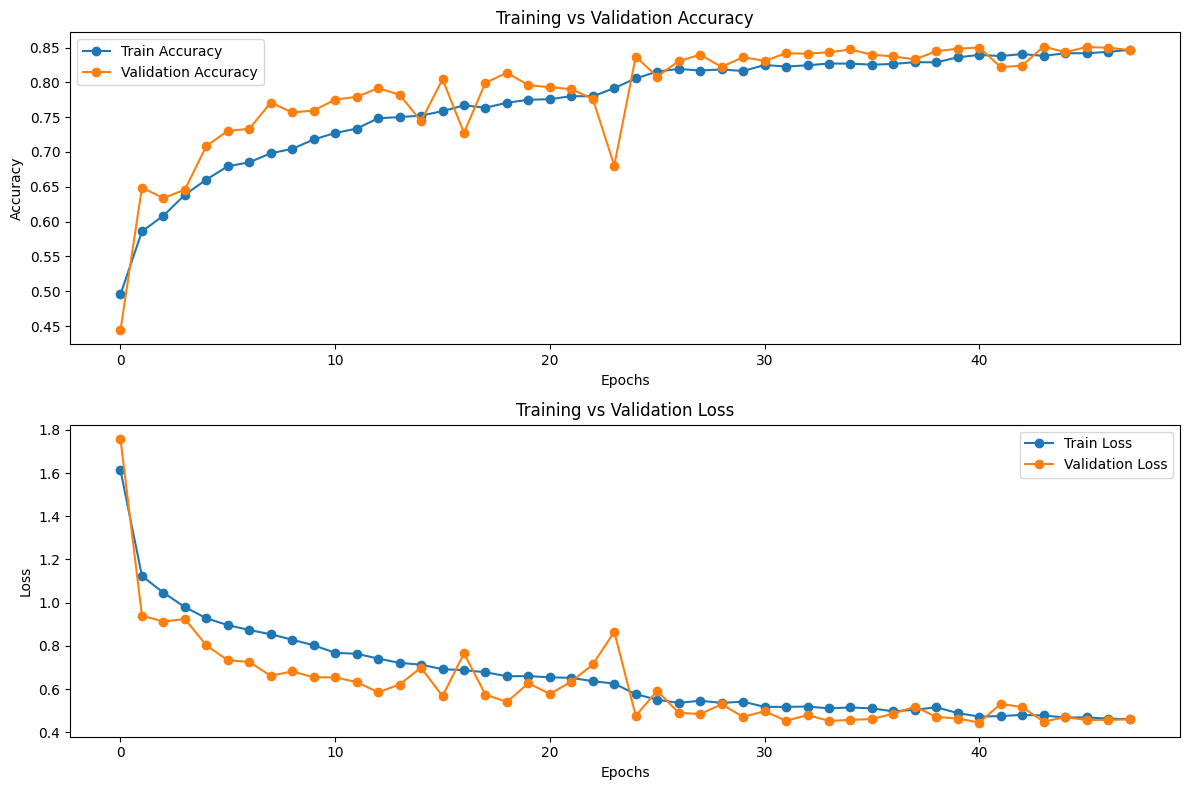

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8577 - loss: 0.4515

Test loss: 0.4515
Test accuracy: 0.8577


In [2]:
# 1. Imports og grunnoppsett

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import pandas as pd  # til tabeller

print("TensorFlow:", tf.__version__)

# Paths (tilpasset ditt oppsett)
train_path = Path('seg_train/seg_train')
test_path  = Path('seg_test/seg_test')

# Klasser i Intel-datasettet
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}

# Litt snillere hyperparametere (og for å unngå OOM)
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 250

# 2. Sjekk og skriv ut GPU-informasjon

print("\n=== Enheter som TensorFlow ser ===")
devices = tf.config.list_physical_devices()
for d in devices:
    print("-", d)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU funnet! Liste over GPU-er:")
    for gpu in gpus:
        try:
            details = tf.config.experimental.get_device_details(gpu)
            gpu_name = details.get('device_name', 'ukjent navn')
        except Exception:
            gpu_name = "ukjent navn (kunne ikke hente detaljer)"
        print(f"- {gpu.name}  |  {gpu_name}")
else:
    print("\nIngen GPU funnet – TensorFlow kjører på CPU.")


# 3. load_data: les inn seg_train/seg_train og seg_test/seg_test

def load_data():
    """
    Leser inn trenings- og testbilder fra mapper:
        train_path = seg_train/seg_train
        test_path  = seg_test/seg_test

    Forventer undermapper med navn lik class_names.
    """
    datasets = [str(train_path), str(test_path)]
    output = []

    for dataset in datasets:
        images = []
        labels = []

        print(f"\nLoading {dataset}")

        # hver subfolder = én klasse
        for folder in os.listdir(dataset):
            # hopp over ting som ikke er en av klassene (bare i tilfelle)
            if folder not in class_names_label:
                print(f"  Advarsel: mappe '{folder}' er ikke i class_names, hopper over.")
                continue

            label = class_names_label[folder]
            folder_path = os.path.join(dataset, folder)

            for file in tqdm(os.listdir(folder_path), desc=f"  {folder}", unit="img"):
                img_path = os.path.join(folder_path, file)

                # les og preprocess bilde
                image = cv2.imread(img_path)
                if image is None:
                    # korrupt fil / annet format
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype='float32')
        labels = np.array(labels, dtype='int32')

        output.append((images, labels))

    return output


# Les inn data
(train_images, train_labels), (test_images, test_labels) = load_data()

# shuffle treningsdata
train_images, train_labels = shuffle(train_images, train_labels, random_state=1)

print("\nShapes:")
print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)

# 4. Normaliser pikselverdier til [0, 1]

train_images = train_images / 255.0
test_images  = test_images / 255.0

# Antall samples
n_train = train_labels.shape[0]
n_test  = test_labels.shape[0]

print(f"\nAntall treningsbilder: {n_train}")
print(f"Antall testbilder:     {n_test}")
print(f"Bildestørrelse:        {IMAGE_SIZE} x 3 (RGB)")

# --- Tabell: overordnet datasammendrag ---
summary_df = pd.DataFrame(
    {
        "split": ["train", "test"],
        "num_samples": [n_train, n_test],
        "img_height": [IMAGE_SIZE[0], IMAGE_SIZE[0]],
        "img_width": [IMAGE_SIZE[1], IMAGE_SIZE[1]],
        "num_channels": [3, 3],
    }
)
try:
    display(summary_df.style.set_caption("Datasammendrag"))
except NameError:
    print(summary_df)


# 4b. Class-fordeling per split (tabeller)

def class_distribution(labels, split_name):
    unique, counts = np.unique(labels, return_counts=True)
    idx_to_name = {v: k for k, v in class_names_label.items()}
    data = {
        "class_index": unique,
        "class_name": [idx_to_name[i] for i in unique],
        "count": counts,
        "fraction": counts / counts.sum(),
    }
    df = pd.DataFrame(data)
    df = df.sort_values("class_index").reset_index(drop=True)
    df["split"] = split_name
    return df


train_dist = class_distribution(train_labels, "train")
test_dist  = class_distribution(test_labels, "test")

try:
    display(train_dist.style.set_caption("Class-fordeling – Train"))
    display(test_dist.style.set_caption("Class-fordeling – Test"))
except NameError:
    print(train_dist)
    print(test_dist)


# 5. Plot noen tilfeldige treningsbilder med labels

def show_random_examples(images, labels, class_names, n=9):
    indices = np.random.choice(len(images), size=n, replace=False)

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[idx])
        plt.title(class_names[labels[idx]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_random_examples(train_images, train_labels, class_names, n=9)


# 6. Definer CNN-modellen med data-augmentering og litt sterkere regularisering

def create_model():
    model = models.Sequential([
        # Data-augmentering (kun aktiv i trening)
        layers.RandomFlip("horizontal", input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # 1. Conv-blokk
        layers.Conv2D(
            filters=64,
            kernel_size=(5, 5),
            padding='valid',
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.BatchNormalization(),

        # 2. Conv-blokk
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding='valid',
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.BatchNormalization(),

        # 3. Conv-blokk
        layers.Conv2D(
            filters=16,
            kernel_size=(3, 3),
            padding='valid',
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(0.0001)
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.BatchNormalization(),

        # Flatten + dense-lag
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.6),   # litt høyere dropout for mindre overfitting

        # Output-lag: én node per klasse
        layers.Dense(len(class_names), activation='softmax')
    ])
    return model


cnn_model = create_model()
cnn_model.summary()


# 7. Kompiler og tren modellen med ReduceLROnPlateau + EarlyStopping

optimizer = keras.optimizers.Adam(learning_rate=0.001)

lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=np.sqrt(0.1),
    patience=5,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,              # hvor mange epochs uten forbedring før vi stopper
    restore_best_weights=True,
    verbose=1
)

# labelene dine er heltall 0–5 → bruk SparseCategoricalCrossentropy
loss_fn = keras.losses.SparseCategoricalCrossentropy()

cnn_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

history = cnn_model.fit(
    train_images,
    train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # 20 % av train brukes som validation
    verbose=2,
    callbacks=[lr_callback, early_stop]
)


# 8. Plot trenings- og valideringskurver

train_accuracy = history.history['accuracy']
val_accuracy   = history.history['val_accuracy']
train_loss     = history.history['loss']
val_loss       = history.history['val_loss']

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

ax[0].set_title('Training vs Validation Accuracy')
ax[0].plot(train_accuracy, 'o-', label='Train Accuracy')
ax[0].plot(val_accuracy, 'o-', label='Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='best')

ax[1].set_title('Training vs Validation Loss')
ax[1].plot(train_loss, 'o-', label='Train Loss')
ax[1].plot(val_loss, 'o-', label='Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()


# 9. Evaluer på testsettet

test_loss, test_acc = cnn_model.evaluate(test_images, test_labels, verbose=1)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


TensorFlow: 2.20.0

=== Enheter som TensorFlow ser ===
- PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU funnet! Liste over GPU-er:
- /physical_device:GPU:0  |  NVIDIA GeForce RTX 2080

Loading seg_train/seg_train


  street: 100%|██████████| 2382/2382 [00:15<00:00, 154.56img/s]



Loading seg_test/seg_test


  street: 100%|██████████| 501/501 [00:02<00:00, 176.54img/s]



Shapes:
train_images: (14034, 128, 128, 3)
train_labels: (14034,)
test_images: (3000, 128, 128, 3)
test_labels: (3000,)

Antall treningsbilder: 14034
Antall testbilder:     3000
Bildestørrelse:        (128, 128) x 3 (RGB)


,split,num_samples,img_height,img_width,num_channels
0,train,14034,128,128,3
1,test,3000,128,128,3


,class_index,class_name,count,fraction,split
0,0,mountain,2512,0.178994,train
1,1,street,2382,0.169731,train
2,2,glacier,2404,0.171298,train
3,3,buildings,2191,0.156121,train
4,4,sea,2274,0.162035,train
5,5,forest,2271,0.161821,train


,class_index,class_name,count,fraction,split
0,0,mountain,525,0.175000,test
1,1,street,501,0.167000,test
2,2,glacier,553,0.184333,test
3,3,buildings,437,0.145667,test
4,4,sea,510,0.170000,test
5,5,forest,474,0.158000,test


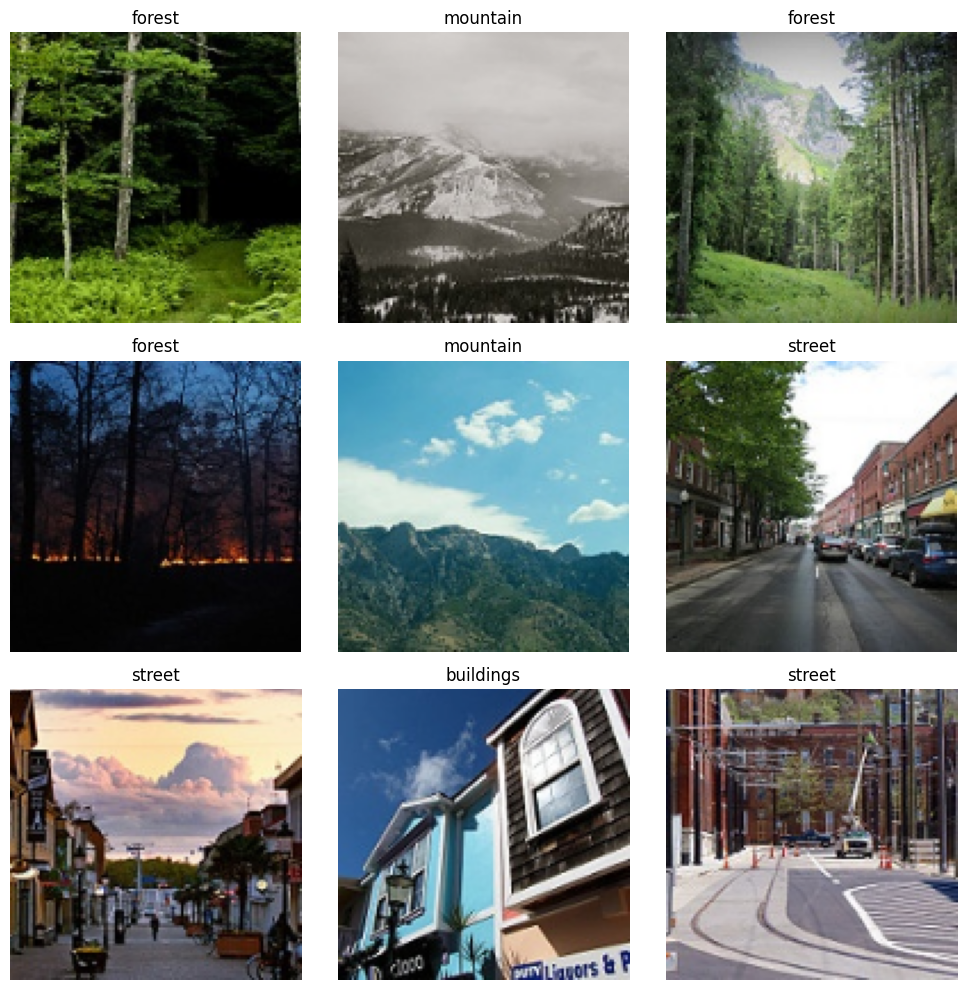

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

2025-12-06 17:35:52.129531: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2207318016 exceeds 10% of free system memory.


Epoch 1/100
702/702 - 34s - 48ms/step - accuracy: 0.8105 - loss: 0.5159 - val_accuracy: 0.9070 - val_loss: 0.2494 - learning_rate: 1.0000e-03
Epoch 2/100
702/702 - 26s - 37ms/step - accuracy: 0.8617 - loss: 0.3853 - val_accuracy: 0.9035 - val_loss: 0.2453 - learning_rate: 1.0000e-03
Epoch 3/100
702/702 - 25s - 35ms/step - accuracy: 0.8679 - loss: 0.3609 - val_accuracy: 0.9049 - val_loss: 0.2463 - learning_rate: 1.0000e-03
Epoch 4/100
702/702 - 25s - 36ms/step - accuracy: 0.8719 - loss: 0.3473 - val_accuracy: 0.8963 - val_loss: 0.2743 - learning_rate: 1.0000e-03
Epoch 5/100
702/702 - 26s - 37ms/step - accuracy: 0.8765 - loss: 0.3423 - val_accuracy: 0.9134 - val_loss: 0.2320 - learning_rate: 1.0000e-03
Epoch 6/100
702/702 - 24s - 35ms/step - accuracy: 0.8794 - loss: 0.3280 - val_accuracy: 0.9102 - val_loss: 0.2402 - learning_rate: 1.0000e-03
Epoch 7/100
702/702 - 26s - 37ms/step - accuracy: 0.8832 - loss: 0.3250 - val_accuracy: 0.9042 - val_loss: 0.2491 - learning_rate: 1.0000e-03
Epoch 

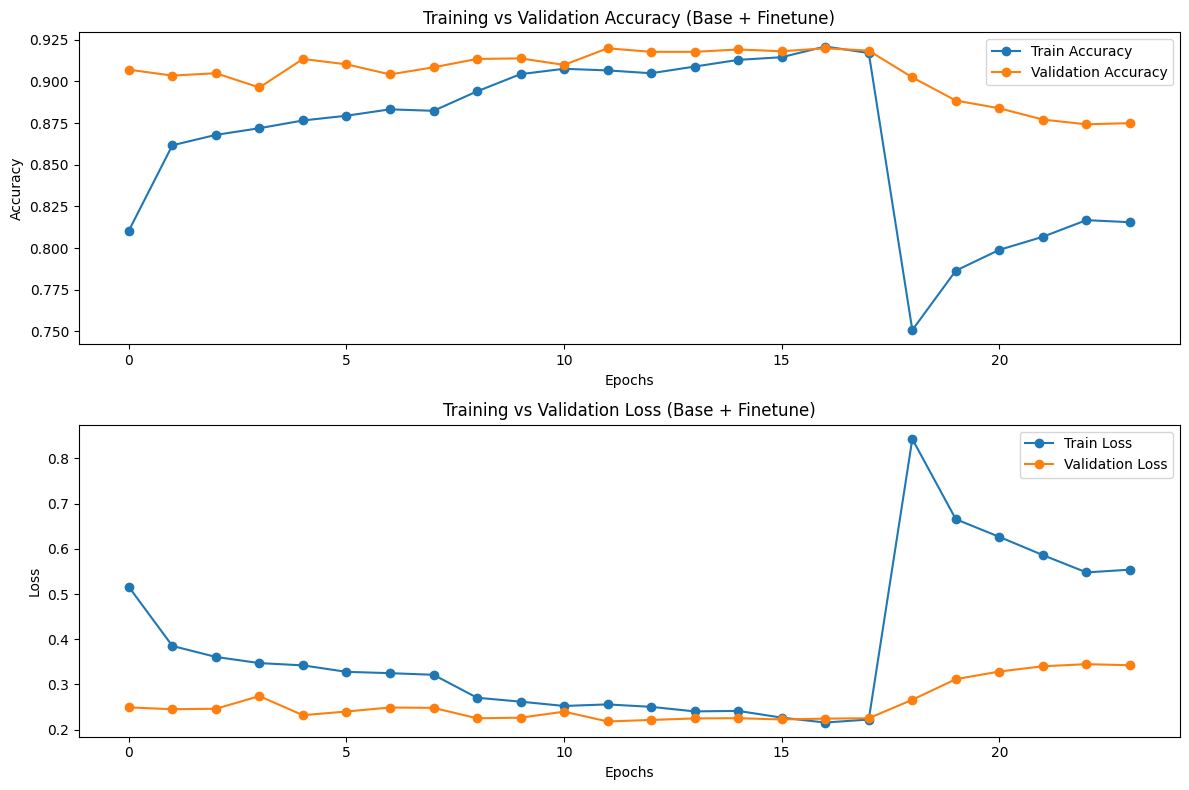

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8970 - loss: 0.3005

Test loss: 0.3005
Test accuracy: 0.8970


In [2]:
# 1. Imports og grunnoppsett

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import pandas as pd  # til tabeller

print("TensorFlow:", tf.__version__)

# Paths (tilpasset ditt oppsett)
train_path = Path('seg_train/seg_train')
test_path  = Path('seg_test/seg_test')

# Klasser i Intel-datasettet
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}

# Hyperparametere
IMAGE_SIZE = (128, 128)      # kan økes til (160,160) hvis du har mer minne
BATCH_SIZE = 16              # sett til 8 hvis du får OOM
EPOCHS_BASE =100             # første treningsfase (frozen base)
EPOCHS_FINE = 50             # ekstra epochs for finetuning

# 2. Sjekk og skriv ut GPU-informasjon

print("\n=== Enheter som TensorFlow ser ===")
devices = tf.config.list_physical_devices()
for d in devices:
    print("-", d)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU funnet! Liste over GPU-er:")
    for gpu in gpus:
        try:
            details = tf.config.experimental.get_device_details(gpu)
            gpu_name = details.get('device_name', 'ukjent navn')
        except Exception:
            gpu_name = "ukjent navn (kunne ikke hente detaljer)"
        print(f"- {gpu.name}  |  {gpu_name}")
else:
    print("\nIngen GPU funnet – TensorFlow kjører på CPU.")


# 3. load_data: les inn seg_train/seg_train og seg_test/seg_test

def load_data():
    """
    Leser inn trenings- og testbilder fra mapper:
        train_path = seg_train/seg_train
        test_path  = seg_test/seg_test

    Forventer undermapper med navn lik class_names.
    """
    datasets = [str(train_path), str(test_path)]
    output = []

    for dataset in datasets:
        images = []
        labels = []

        print(f"\nLoading {dataset}")

        # hver subfolder = én klasse
        for folder in os.listdir(dataset):
            # hopp over ting som ikke er en av klassene (bare i tilfelle)
            if folder not in class_names_label:
                print(f"  Advarsel: mappe '{folder}' er ikke i class_names, hopper over.")
                continue

            label = class_names_label[folder]
            folder_path = os.path.join(dataset, folder)

            for file in tqdm(os.listdir(folder_path), desc=f"  {folder}", unit="img"):
                img_path = os.path.join(folder_path, file)

                # les og preprocess bilde
                image = cv2.imread(img_path)
                if image is None:
                    # korrupt fil / annet format
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype='float32')
        labels = np.array(labels, dtype='int32')

        output.append((images, labels))

    return output


# Les inn data
(train_images, train_labels), (test_images, test_labels) = load_data()

# shuffle treningsdata
train_images, train_labels = shuffle(train_images, train_labels, random_state=1)

print("\nShapes:")
print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)

# 4. Preprocessing: bruk MobileNetV2 sin preprocess_input
# Denne forventer 0–255 float32, og skalerer til [-1, 1]

train_images = preprocess_input(train_images)
test_images  = preprocess_input(test_images)

# Antall samples
n_train = train_labels.shape[0]
n_test  = test_labels.shape[0]

print(f"\nAntall treningsbilder: {n_train}")
print(f"Antall testbilder:     {n_test}")
print(f"Bildestørrelse:        {IMAGE_SIZE} x 3 (RGB)")

# --- Tabell: overordnet datasammendrag ---
summary_df = pd.DataFrame(
    {
        "split": ["train", "test"],
        "num_samples": [n_train, n_test],
        "img_height": [IMAGE_SIZE[0], IMAGE_SIZE[0]],
        "img_width": [IMAGE_SIZE[1], IMAGE_SIZE[1]],
        "num_channels": [3, 3],
    }
)
try:
    display(summary_df.style.set_caption("Datasammendrag"))
except NameError:
    print(summary_df)


# 4b. Class-fordeling per split (tabeller)

def class_distribution(labels, split_name):
    unique, counts = np.unique(labels, return_counts=True)
    idx_to_name = {v: k for k, v in class_names_label.items()}
    data = {
        "class_index": unique,
        "class_name": [idx_to_name[i] for i in unique],
        "count": counts,
        "fraction": counts / counts.sum(),
    }
    df = pd.DataFrame(data)
    df = df.sort_values("class_index").reset_index(drop=True)
    df["split"] = split_name
    return df


train_dist = class_distribution(train_labels, "train")
test_dist  = class_distribution(test_labels, "test")

try:
    display(train_dist.style.set_caption("Class-fordeling – Train"))
    display(test_dist.style.set_caption("Class-fordeling – Test"))
except NameError:
    print(train_dist)
    print(test_dist)


# 5. Plot noen tilfeldige treningsbilder med labels
# (etter preprocess_input må vi skalere tilbake til [0,1] for visning)

def show_random_examples(images, labels, class_names, n=9):
    indices = np.random.choice(len(images), size=n, replace=False)

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        ax = plt.subplot(3, 3, i + 1)
        img = (images[idx] + 1.0) / 2.0  # [-1,1] -> [0,1]
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(class_names[labels[idx]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_random_examples(train_images, train_labels, class_names, n=9)


# 6. Data-augmentering + MobileNetV2-basemodell

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

# Bygg base-modellen (pretrained)
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # først: frys hele basen


def create_model():
    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # viktig: training=False når basen er fryst
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(len(class_names), activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model


cnn_model = create_model()
cnn_model.summary()


# 7. Første treningsfase (basen fryst)

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=np.sqrt(0.1),
    patience=3,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

loss_fn = keras.losses.SparseCategoricalCrossentropy()

cnn_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

history_base = cnn_model.fit(
    train_images,
    train_labels,
    epochs=EPOCHS_BASE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=2,
    callbacks=[lr_callback, early_stop]
)


# 8. Finetuning: lås opp de siste lagene i base_model

base_model.trainable = True

# Lås fortsatt de første lagene (de er generelle features).
# Her låser vi opp de siste ~40 lagene. Justér tallet ved behov. var 40 fikk da 90
fine_tune_at = len(base_model.layers) - 20 

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss=loss_fn,
    metrics=['accuracy']
)

print("\nStarter finetuning...")

history_fine = cnn_model.fit(
    train_images,
    train_labels,
    epochs=EPOCHS_FINE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=2,
    callbacks=[lr_callback, early_stop]
)


# 9. Slå sammen historikk for plotting

def combine_histories(h1, h2):
    history = {}
    for k in h1.history.keys():
        history[k] = h1.history[k] + h2.history[k]
    return history

history_combined = combine_histories(history_base, history_fine)

train_accuracy = history_combined['accuracy']
val_accuracy   = history_combined['val_accuracy']
train_loss     = history_combined['loss']
val_loss       = history_combined['val_loss']

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

ax[0].set_title('Training vs Validation Accuracy (Base + Finetune)')
ax[0].plot(train_accuracy, 'o-', label='Train Accuracy')
ax[0].plot(val_accuracy, 'o-', label='Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='best')

ax[1].set_title('Training vs Validation Loss (Base + Finetune)')
ax[1].plot(train_loss, 'o-', label='Train Loss')
ax[1].plot(val_loss, 'o-', label='Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()


# 10. Evaluer på testsettet

test_loss, test_acc = cnn_model.evaluate(test_images, test_labels, verbose=1)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


2025-12-09 11:02:47.014555: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0

Loading seg_train/seg_train


street: 100%|██████████| 2382/2382 [00:34<00:00, 69.00img/s]



Loading seg_test/seg_test


street: 100%|██████████| 501/501 [00:08<00:00, 55.89img/s]


...

 Non-trainable params: 0 (0.00 B)

2025-12-09 11:07:00.179010: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2483159040 exceeds 10% of free system memory.
2025-12-09 11:07:02.787984: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2483159040 exceeds 10% of free system memory.


Epoch 1/400


E0000 00:00:1765274827.445211    1297 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-12-09 11:07:09.730651: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


790/790 - 47s - 59ms/step - accuracy: 0.3297 - loss: 2.0689 - val_accuracy: 0.3597 - val_loss: 1.5439 - learning_rate: 8.0000e-04
Epoch 2/400
790/790 - 38s - 49ms/step - accuracy: 0.3416 - loss: 1.4948 - val_accuracy: 0.3084 - val_loss: 1.4238 - learning_rate: 8.0000e-04
Epoch 3/400
790/790 - 38s - 48ms/step - accuracy: 0.3740 - loss: 1.4236 - val_accuracy: 0.4573 - val_loss: 1.1426 - learning_rate: 8.0000e-04
Epoch 4/400
790/790 - 38s - 48ms/step - accuracy: 0.4203 - loss: 1.3432 - val_accuracy: 0.3903 - val_loss: 1.2877 - learning_rate: 8.0000e-04
Epoch 5/400
790/790 - 40s - 51ms/step - accuracy: 0.4703 - loss: 1.2270 - val_accuracy: 0.5598 - val_loss: 1.0759 - learning_rate: 8.0000e-04
Epoch 6/400
790/790 - 38s - 48ms/step - accuracy: 0.5262 - loss: 1.1449 - val_accuracy: 0.6453 - val_loss: 0.9002 - learning_rate: 8.0000e-04
Epoch 7/400
790/790 - 38s - 48ms/step - accuracy: 0.5830 - loss: 1.0405 - val_accuracy: 0.6709 - val_loss: 0.8994 - learning_rate: 8.0000e-04
Epoch 8/400
790/79

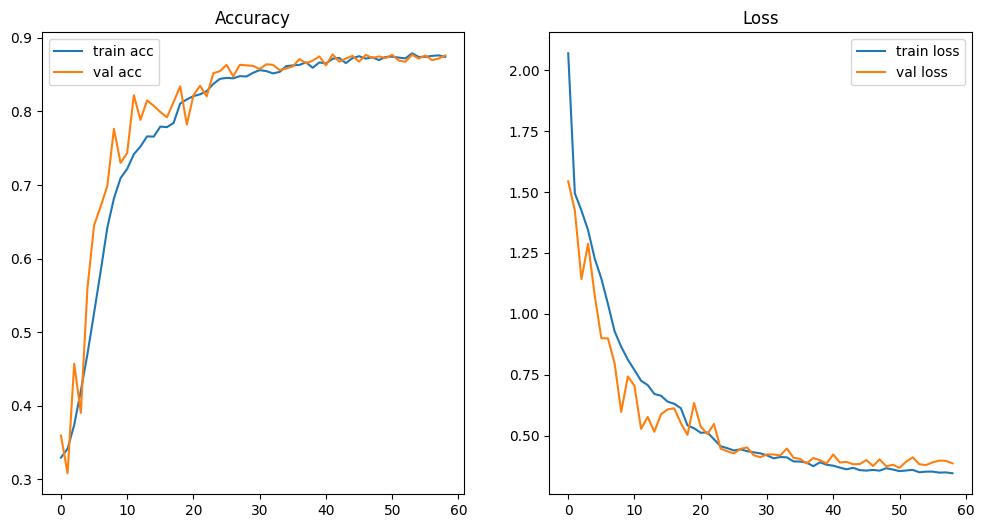

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8717 - loss: 0.3638

TEST ACCURACY: 0.8717
TEST LOSS:     0.3638


In [1]:
# 1. Imports og grunnoppsett

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import pandas as pd

print("TensorFlow:", tf.__version__)

# Paths
train_path = Path('seg_train/seg_train')
test_path  = Path('seg_test/seg_test')

# Klasser
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {name: i for i, name in enumerate(class_names)}

# Hyperparams
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16 #16 best med 87 før prøver denner 
EPOCHS = 400   # 60–80 er vanlig for scratch-CNN


# 2. last inn data -----------------------------------------------------

def load_data():
    datasets = [str(train_path), str(test_path)]
    output = []

    for dataset in datasets:
        images, labels = [], []
        print(f"\nLoading {dataset}")

        for folder in os.listdir(dataset):

            if folder not in class_names_label:
                continue

            label = class_names_label[folder]
            folder_path = os.path.join(dataset, folder)

            for file in tqdm(os.listdir(folder_path), desc=folder, unit="img"):
                img_path = os.path.join(folder_path, file)
                image = cv2.imread(img_path)

                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype="float32")
        labels = np.array(labels, dtype="int32")
        output.append((images, labels))

    return output


(train_images, train_labels), (test_images, test_labels) = load_data()

train_images, train_labels = shuffle(train_images, train_labels, random_state=42)

# Normaliser
train_images = train_images / 255.0
test_images  = test_images / 255.0

print(train_images.shape, test_images.shape)


# 3. Data augmentering --------------------------------------------------

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15)
])


# 4. CNN-MODELL FRA SCRATCH --------------------------------------------

def create_model():
    model = models.Sequential([

        # augmentering
        data_augmentation,

        # --- Feature extractor ---
        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.40),

        # --- Classifier ---
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.50),
        layers.Dense(len(class_names), activation="softmax")
    ])

    return model


model = create_model()
model.summary()


# 5. Compile -------------------------------------------------------------

optimizer = keras.optimizers.Adam(learning_rate=0.0008)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# 6. Train ---------------------------------------------------------------

history = model.fit(
    train_images,
    train_labels,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[lr_callback, early_stop],
    verbose=2
)


# 7. Plot ---------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="train acc")
plt.plot(history.history['val_accuracy'], label="val acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="train loss")
plt.plot(history.history['val_loss'], label="val loss")
plt.legend(); plt.title("Loss")
plt.show()


# 8. Evaluate -----------------------------------------------------------

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=1)
print(f"\nTEST ACCURACY: {test_acc:.4f}")
print(f"TEST LOSS:     {test_loss:.4f}")


In [ ]:
# 6. CNN-modell med Flatten i stedet for GAP

model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # Flatten i stedet for GAP
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()




I0000 00:00:1764865570.912106     987 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6063 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,898,246 (11.06 MB)

 Trainable params: 2,897,542 (11.05 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# 6. CNN-modell med GlobalAveragePooling2D i stedet for Flatten

# Data augmentation (må defineres først)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

    # Påfør augmentation (bare aktiv i trening)
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    # 🔽 Her er forskjellen: GlobalAveragePooling2D i stedet for Flatten
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,806 (1.06 MB)

 Trainable params: 276,102 (1.05 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# 7. Tren modellen
history = model.fit(
    train_images,
    train_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,  # tilsvarende det originalen gjør
    verbose=1
)


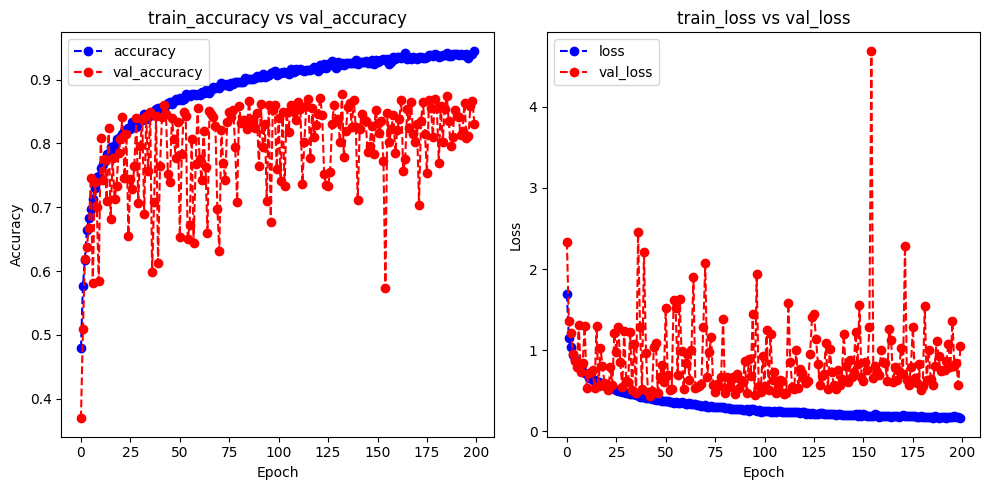

In [ ]:
# 7c. Plott accuracy og loss

def plot_accuracy_loss(history):
    fig = plt.figure(figsize=(10, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], 'bo--', label='accuracy')
    plt.plot(history.history['val_accuracy'], 'ro--', label='val_accuracy')
    plt.title("train_accuracy vs val_accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], 'bo--', label='loss')
    plt.plot(history.history['val_loss'], 'ro--', label='val_loss')
    plt.title("train_loss vs val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_accuracy_loss(history)


In [ ]:
# 8. Evaluer modellen på testsettet

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=1)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8207 - loss: 1.1387

Test loss: 1.1387
Test accuracy: 0.8207


TensorFlow: 2.20.0

=== Enheter som TensorFlow ser ===
- PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU funnet! Liste over GPU-er:
- /physical_device:GPU:0  |  NVIDIA GeForce RTX 2080

Loading seg_train/seg_train


  street: 100%|██████████| 2382/2382 [00:11<00:00, 199.67img/s]



Loading seg_test/seg_test


  street: 100%|██████████| 501/501 [00:02<00:00, 207.88img/s]



Shapes:
train_images: (14034, 128, 128, 3)
train_labels: (14034,)
test_images: (3000, 128, 128, 3)
test_labels: (3000,)

Antall treningsbilder: 14034
Antall testbilder:     3000
Bildestørrelse:        (128, 128) x 3 (grayscale replikert til RGB)


,split,num_samples,img_height,img_width,num_channels
0,train,14034,128,128,3
1,test,3000,128,128,3


,class_index,class_name,count,fraction,split
0,0,mountain,2512,0.178994,train
1,1,street,2382,0.169731,train
2,2,glacier,2404,0.171298,train
3,3,buildings,2191,0.156121,train
4,4,sea,2274,0.162035,train
5,5,forest,2271,0.161821,train


,class_index,class_name,count,fraction,split
0,0,mountain,525,0.175000,test
1,1,street,501,0.167000,test
2,2,glacier,553,0.184333,test
3,3,buildings,437,0.145667,test
4,4,sea,510,0.170000,test
5,5,forest,474,0.158000,test


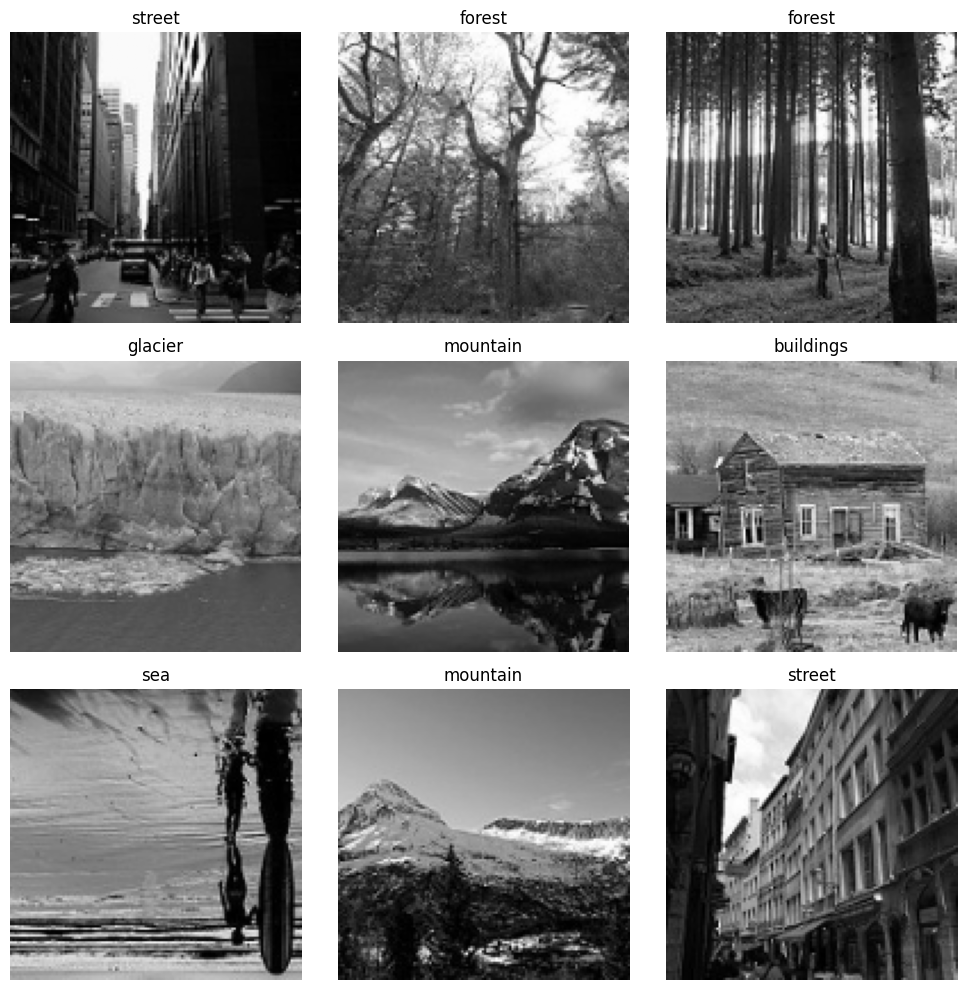

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

2025-12-09 11:46:41.395726: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2207318016 exceeds 10% of free system memory.
2025-12-09 11:46:43.230305: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2207318016 exceeds 10% of free system memory.


Epoch 1/100
702/702 - 32s - 45ms/step - accuracy: 0.7766 - loss: 0.6042 - val_accuracy: 0.8750 - val_loss: 0.3294 - learning_rate: 1.0000e-03
Epoch 2/100
702/702 - 23s - 33ms/step - accuracy: 0.8236 - loss: 0.4747 - val_accuracy: 0.8810 - val_loss: 0.3039 - learning_rate: 1.0000e-03
Epoch 3/100
702/702 - 26s - 37ms/step - accuracy: 0.8311 - loss: 0.4588 - val_accuracy: 0.8828 - val_loss: 0.3079 - learning_rate: 1.0000e-03
Epoch 4/100
702/702 - 25s - 35ms/step - accuracy: 0.8407 - loss: 0.4270 - val_accuracy: 0.8685 - val_loss: 0.3347 - learning_rate: 1.0000e-03
Epoch 5/100
702/702 - 22s - 32ms/step - accuracy: 0.8421 - loss: 0.4227 - val_accuracy: 0.8849 - val_loss: 0.2937 - learning_rate: 1.0000e-03
Epoch 6/100
702/702 - 25s - 36ms/step - accuracy: 0.8482 - loss: 0.4046 - val_accuracy: 0.8910 - val_loss: 0.2893 - learning_rate: 1.0000e-03
Epoch 7/100
702/702 - 25s - 35ms/step - accuracy: 0.8505 - loss: 0.4046 - val_accuracy: 0.8853 - val_loss: 0.2951 - learning_rate: 1.0000e-03
Epoch 

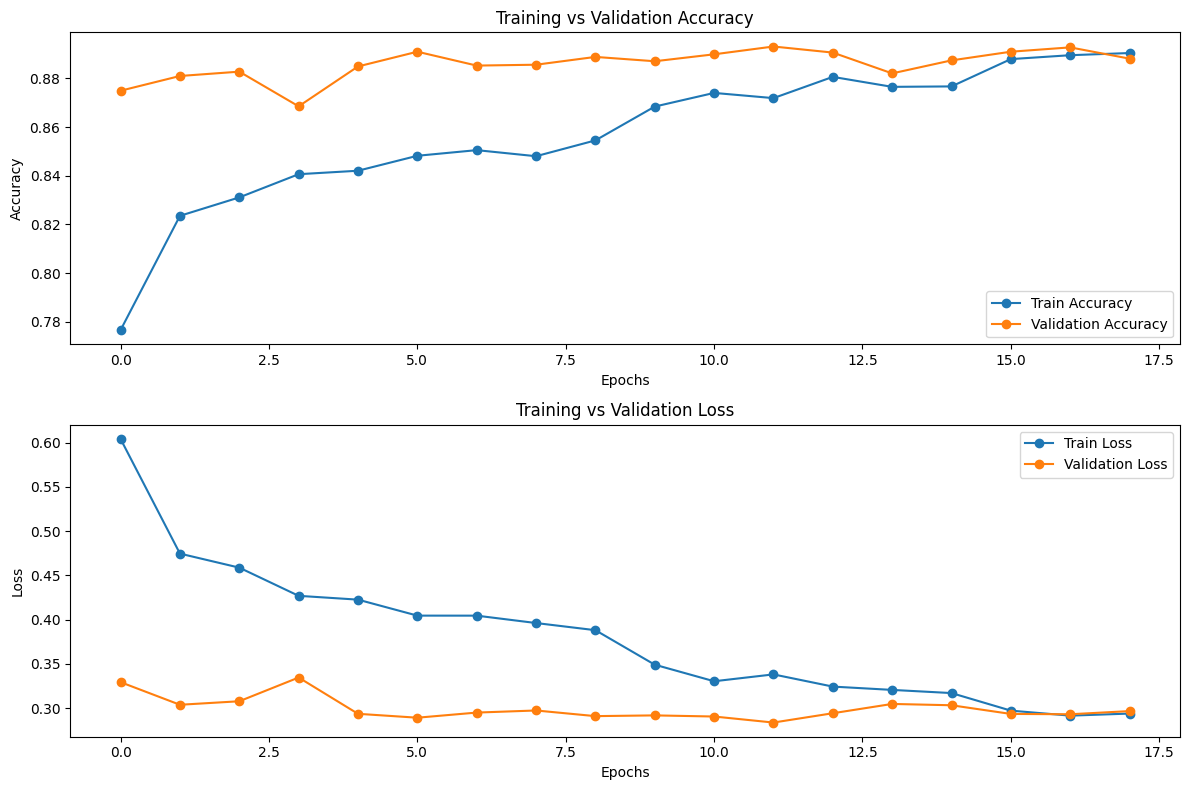

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8807 - loss: 0.3176

Test loss: 0.3176
Test accuracy: 0.8807


In [2]:
# 1. Imports og grunnoppsett med grayscale (UTEN finetuning)

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import pandas as pd  # til tabeller

print("TensorFlow:", tf.__version__)

# Paths (tilpasset ditt oppsett)
train_path = Path('seg_train/seg_train')
test_path  = Path('seg_test/seg_test')

# Klasser i Intel-datasettet
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}

# Hyperparametere
IMAGE_SIZE = (128, 128)      # kan økes til (160,160) hvis du har mer minne
BATCH_SIZE = 16              # sett til 8 hvis du får OOM
EPOCHS = 100                 # én treningsfase, ingen finetuning

# 2. Sjekk og skriv ut GPU-informasjon

print("\n=== Enheter som TensorFlow ser ===")
devices = tf.config.list_physical_devices()
for d in devices:
    print("-", d)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU funnet! Liste over GPU-er:")
    for gpu in gpus:
        try:
            details = tf.config.experimental.get_device_details(gpu)
            gpu_name = details.get('device_name', 'ukjent navn')
        except Exception:
            gpu_name = "ukjent navn (kunne ikke hente detaljer)"
        print(f"- {gpu.name}  |  {gpu_name}")
else:
    print("\nIngen GPU funnet – TensorFlow kjører på CPU.")


# 3. load_data: les inn seg_train/seg_train og seg_test/seg_test
#    MED GRÅSKALA-PREPROSESSERING

def load_data():
    """
    Leser inn trenings- og testbilder fra mapper:
        train_path = seg_train/seg_train
        test_path  = seg_test/seg_test

    Forventer undermapper med navn lik class_names.

    Alle bilder leses som grayscale og konverteres deretter til
    3-kanals RGB (samme gråverdi i R, G og B).
    """
    datasets = [str(train_path), str(test_path)]
    output = []

    for dataset in datasets:
        images = []
        labels = []

        print(f"\nLoading {dataset}")

        # hver subfolder = én klasse
        for folder in os.listdir(dataset):
            # hopp over ting som ikke er en av klassene (bare i tilfelle)
            if folder not in class_names_label:
                print(f"  Advarsel: mappe '{folder}' er ikke i class_names, hopper over.")
                continue

            label = class_names_label[folder]
            folder_path = os.path.join(dataset, folder)

            for file in tqdm(os.listdir(folder_path), desc=f"  {folder}", unit="img"):
                img_path = os.path.join(folder_path, file)

                # --- LES SOM GRÅSKALA ---
                image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    # korrupt fil / annet format
                    continue

                # resize til ønsket størrelse
                image = cv2.resize(image, IMAGE_SIZE)

                # konverter til 3-kanals "RGB" ved å kopiere gråverdien
                # (MobileNetV2 forventer 3 kanaler)
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype='float32')
        labels = np.array(labels, dtype='int32')

        output.append((images, labels))

    return output


# Les inn data
(train_images, train_labels), (test_images, test_labels) = load_data()

# shuffle treningsdata
train_images, train_labels = shuffle(train_images, train_labels, random_state=1)

print("\nShapes:")
print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)

# 4. Preprocessing: bruk MobileNetV2 sin preprocess_input
# Bildene er nå i grayscale, men duplisert til 3 kanaler (R=G=B).
# preprocess_input forventer 0–255 float32 og skalerer til [-1, 1].

train_images = preprocess_input(train_images)
test_images  = preprocess_input(test_images)

# Antall samples
n_train = train_labels.shape[0]
n_test  = test_labels.shape[0]

print(f"\nAntall treningsbilder: {n_train}")
print(f"Antall testbilder:     {n_test}")
print(f"Bildestørrelse:        {IMAGE_SIZE} x 3 (grayscale replikert til RGB)")

# --- Tabell: overordnet datasammendrag ---
summary_df = pd.DataFrame(
    {
        "split": ["train", "test"],
        "num_samples": [n_train, n_test],
        "img_height": [IMAGE_SIZE[0], IMAGE_SIZE[0]],
        "img_width": [IMAGE_SIZE[1], IMAGE_SIZE[1]],
        "num_channels": [3, 3],  # fortsatt 3 kanaler, men alle er grå
    }
)
try:
    display(summary_df.style.set_caption("Datasammendrag"))
except NameError:
    print(summary_df)


# 4b. Class-fordeling per split (tabeller)

def class_distribution(labels, split_name):
    unique, counts = np.unique(labels, return_counts=True)
    idx_to_name = {v: k for k, v in class_names_label.items()}
    data = {
        "class_index": unique,
        "class_name": [idx_to_name[i] for i in unique],
        "count": counts,
        "fraction": counts / counts.sum(),
    }
    df = pd.DataFrame(data)
    df = df.sort_values("class_index").reset_index(drop=True)
    df["split"] = split_name
    return df


train_dist = class_distribution(train_labels, "train")
test_dist  = class_distribution(test_labels, "test")

try:
    display(train_dist.style.set_caption("Class-fordeling – Train"))
    display(test_dist.style.set_caption("Class-fordeling – Test"))
except NameError:
    print(train_dist)
    print(test_dist)


# 5. Plot noen tilfeldige treningsbilder med labels
# (etter preprocess_input må vi skalere tilbake til [0,1] for visning)

def show_random_examples(images, labels, class_names, n=9):
    indices = np.random.choice(len(images), size=n, replace=False)

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        ax = plt.subplot(3, 3, i + 1)
        img = (images[idx] + 1.0) / 2.0  # [-1,1] -> [0,1]
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(class_names[labels[idx]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_random_examples(train_images, train_labels, class_names, n=9)


# 6. Data-augmentering + MobileNetV2-basemodell

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

# Bygg base-modellen (pretrained)
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # vi bruker bare feature-ekstraksjon, ingen finetuning


def create_model():
    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # viktig: training=False når basen er fryst
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(len(class_names), activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model


cnn_model = create_model()
cnn_model.summary()


# 7. Treningsfase (kun én, ingen finetuning)

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=np.sqrt(0.1),
    patience=3,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

loss_fn = keras.losses.SparseCategoricalCrossentropy()

cnn_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

history = cnn_model.fit(
    train_images,
    train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=2,
    callbacks=[lr_callback, early_stop]
)


# 8. Plot treningshistorikk (én fase)

train_accuracy = history.history['accuracy']
val_accuracy   = history.history['val_accuracy']
train_loss     = history.history['loss']
val_loss       = history.history['val_loss']

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

ax[0].set_title('Training vs Validation Accuracy')
ax[0].plot(train_accuracy, 'o-', label='Train Accuracy')
ax[0].plot(val_accuracy, 'o-', label='Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='best')

ax[1].set_title('Training vs Validation Loss')
ax[1].plot(train_loss, 'o-', label='Train Loss')
ax[1].plot(val_loss, 'o-', label='Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()


# 9. Evaluer på testsettet

test_loss, test_acc = cnn_model.evaluate(test_images, test_labels, verbose=1)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


TensorFlow: 2.20.0

=== Enheter som TensorFlow ser ===
- PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
- PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU funnet! Liste over GPU-er:
- /physical_device:GPU:0  |  NVIDIA GeForce RTX 2080

Loading seg_train/seg_train


  street: 100%|██████████| 2382/2382 [00:34<00:00, 68.46img/s]



Loading seg_test/seg_test


  street: 100%|██████████| 501/501 [00:06<00:00, 77.84img/s]



Shapes:
train_images: (14034, 128, 128, 3)
train_labels: (14034,)
test_images: (3000, 128, 128, 3)
test_labels: (3000,)

Antall treningsbilder: 14034
Antall testbilder:     3000
Bildestørrelse:        (128, 128) x 3 (RGB)


,split,num_samples,img_height,img_width,num_channels
0,train,14034,128,128,3
1,test,3000,128,128,3


,class_index,class_name,count,fraction,split
0,0,mountain,2512,0.178994,train
1,1,street,2382,0.169731,train
2,2,glacier,2404,0.171298,train
3,3,buildings,2191,0.156121,train
4,4,sea,2274,0.162035,train
5,5,forest,2271,0.161821,train


,class_index,class_name,count,fraction,split
0,0,mountain,525,0.175000,test
1,1,street,501,0.167000,test
2,2,glacier,553,0.184333,test
3,3,buildings,437,0.145667,test
4,4,sea,510,0.170000,test
5,5,forest,474,0.158000,test


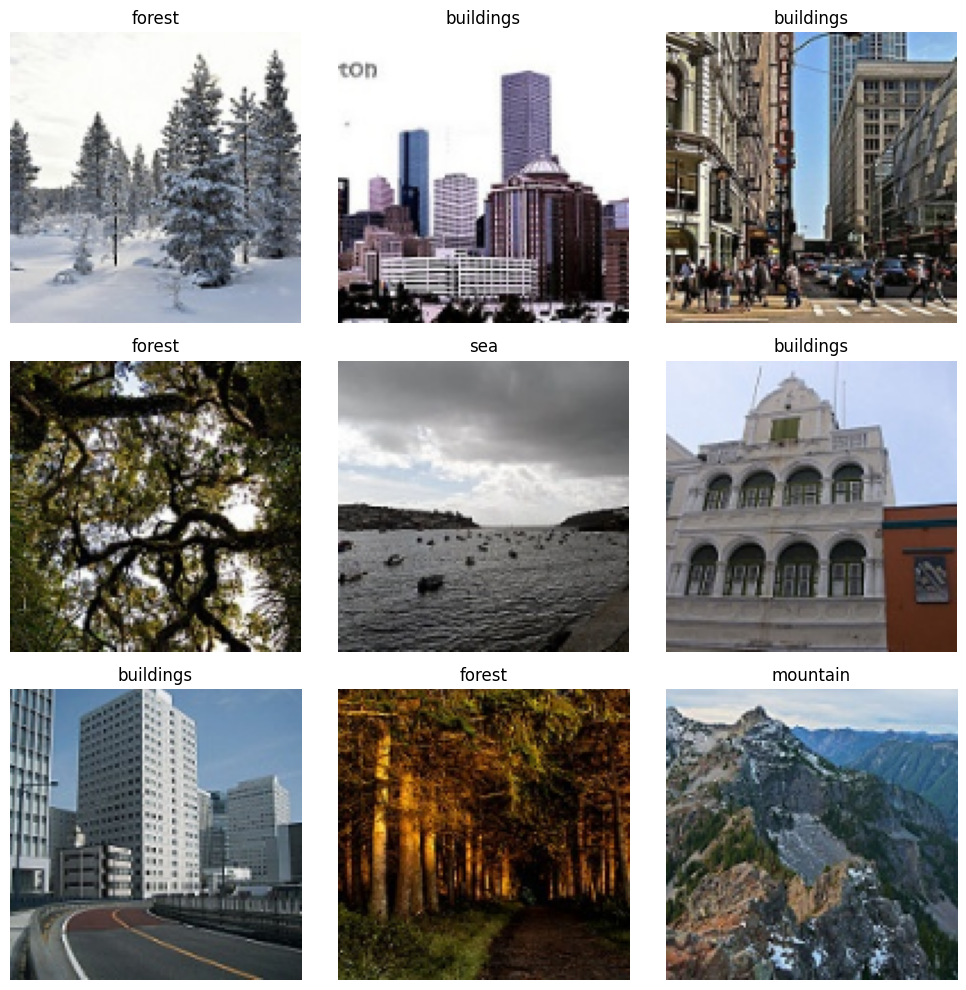

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

2025-12-09 11:58:18.128069: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2207318016 exceeds 10% of free system memory.


Epoch 1/100
702/702 - 29s - 42ms/step - accuracy: 0.8185 - loss: 0.5074 - val_accuracy: 0.8906 - val_loss: 0.2779 - learning_rate: 1.0000e-03
Epoch 2/100


In [ ]:
# 1. Imports og grunnoppsett UTEN finetuning

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import cv2
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import pandas as pd  # til tabeller

print("TensorFlow:", tf.__version__)

# Paths (tilpasset ditt oppsett)
train_path = Path('seg_train/seg_train')
test_path  = Path('seg_test/seg_test')

# Klasser i Intel-datasettet
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}

# Hyperparametere
IMAGE_SIZE = (128, 128)      # kan økes til (160,160) hvis du har mer minne
BATCH_SIZE = 16              # sett til 8 hvis du får OOM
EPOCHS = 100                 # én treningsfase, ingen finetuning

# 2. Sjekk og skriv ut GPU-informasjon

print("\n=== Enheter som TensorFlow ser ===")
devices = tf.config.list_physical_devices()
for d in devices:
    print("-", d)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU funnet! Liste over GPU-er:")
    for gpu in gpus:
        try:
            details = tf.config.experimental.get_device_details(gpu)
            gpu_name = details.get('device_name', 'ukjent navn')
        except Exception:
            gpu_name = "ukjent navn (kunne ikke hente detaljer)"
        print(f"- {gpu.name}  |  {gpu_name}")
else:
    print("\nIngen GPU funnet – TensorFlow kjører på CPU.")


# 3. load_data: les inn seg_train/seg_train og seg_test/seg_test

def load_data():
    """
    Leser inn trenings- og testbilder fra mapper:
        train_path = seg_train/seg_train
        test_path  = seg_test/seg_test

    Forventer undermapper med navn lik class_names.
    """
    datasets = [str(train_path), str(test_path)]
    output = []

    for dataset in datasets:
        images = []
        labels = []

        print(f"\nLoading {dataset}")

        # hver subfolder = én klasse
        for folder in os.listdir(dataset):
            # hopp over ting som ikke er en av klassene (bare i tilfelle)
            if folder not in class_names_label:
                print(f"  Advarsel: mappe '{folder}' er ikke i class_names, hopper over.")
                continue

            label = class_names_label[folder]
            folder_path = os.path.join(dataset, folder)

            for file in tqdm(os.listdir(folder_path), desc=f"  {folder}", unit="img"):
                img_path = os.path.join(folder_path, file)

                # les og preprocess bilde
                image = cv2.imread(img_path)
                if image is None:
                    # korrupt fil / annet format
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)
                labels.append(label)

        images = np.array(images, dtype='float32')
        labels = np.array(labels, dtype='int32')

        output.append((images, labels))

    return output


# Les inn data
(train_images, train_labels), (test_images, test_labels) = load_data()

# shuffle treningsdata
train_images, train_labels = shuffle(train_images, train_labels, random_state=1)

print("\nShapes:")
print("train_images:", train_images.shape)
print("train_labels:", train_labels.shape)
print("test_images:", test_images.shape)
print("test_labels:", test_labels.shape)

# 4. Preprocessing: bruk MobileNetV2 sin preprocess_input
# Denne forventer 0–255 float32, og skalerer til [-1, 1]

train_images = preprocess_input(train_images)
test_images  = preprocess_input(test_images)

# Antall samples
n_train = train_labels.shape[0]
n_test  = test_labels.shape[0]

print(f"\nAntall treningsbilder: {n_train}")
print(f"Antall testbilder:     {n_test}")
print(f"Bildestørrelse:        {IMAGE_SIZE} x 3 (RGB)")

# --- Tabell: overordnet datasammendrag ---
summary_df = pd.DataFrame(
    {
        "split": ["train", "test"],
        "num_samples": [n_train, n_test],
        "img_height": [IMAGE_SIZE[0], IMAGE_SIZE[0]],
        "img_width": [IMAGE_SIZE[1], IMAGE_SIZE[1]],
        "num_channels": [3, 3],
    }
)
try:
    display(summary_df.style.set_caption("Datasammendrag"))
except NameError:
    print(summary_df)


# 4b. Class-fordeling per split (tabeller)

def class_distribution(labels, split_name):
    unique, counts = np.unique(labels, return_counts=True)
    idx_to_name = {v: k for k, v in class_names_label.items()}
    data = {
        "class_index": unique,
        "class_name": [idx_to_name[i] for i in unique],
        "count": counts,
        "fraction": counts / counts.sum(),
    }
    df = pd.DataFrame(data)
    df = df.sort_values("class_index").reset_index(drop=True)
    df["split"] = split_name
    return df


train_dist = class_distribution(train_labels, "train")
test_dist  = class_distribution(test_labels, "test")

try:
    display(train_dist.style.set_caption("Class-fordeling – Train"))
    display(test_dist.style.set_caption("Class-fordeling – Test"))
except NameError:
    print(train_dist)
    print(test_dist)


# 5. Plot noen tilfeldige treningsbilder med labels
# (etter preprocess_input må vi skalere tilbake til [0,1] for visning)

def show_random_examples(images, labels, class_names, n=9):
    indices = np.random.choice(len(images), size=n, replace=False)

    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        ax = plt.subplot(3, 3, i + 1)
        img = (images[idx] + 1.0) / 2.0  # [-1,1] -> [0,1]
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(class_names[labels[idx]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_random_examples(train_images, train_labels, class_names, n=9)


# 6. Data-augmentering + MobileNetV2-basemodell

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

# Bygg base-modellen (pretrained)
base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # vi bruker bare feature-ekstraksjon, ingen finetuning


def create_model():
    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)  # viktig: training=False når basen er fryst
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(len(class_names), activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model


cnn_model = create_model()
cnn_model.summary()


# 7. Treningsfase (kun én, ingen finetuning)

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=np.sqrt(0.1),
    patience=3,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

loss_fn = keras.losses.SparseCategoricalCrossentropy()

cnn_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

history = cnn_model.fit(
    train_images,
    train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=2,
    callbacks=[lr_callback, early_stop]
)


# 8. Plot treningshistorikk (kun én fase)

train_accuracy = history.history['accuracy']
val_accuracy   = history.history['val_accuracy']
train_loss     = history.history['loss']
val_loss       = history.history['val_loss']

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

ax[0].set_title('Training vs Validation Accuracy')
ax[0].plot(train_accuracy, 'o-', label='Train Accuracy')
ax[0].plot(val_accuracy, 'o-', label='Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='best')

ax[1].set_title('Training vs Validation Loss')
ax[1].plot(train_loss, 'o-', label='Train Loss')
ax[1].plot(val_loss, 'o-', label='Validation Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()


# 9. Evaluer på testsettet

test_loss, test_acc = cnn_model.evaluate(test_images, test_labels, verbose=1)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


In [ ]:
# ==========================================================
# 1. Imports og oppsett
# ==========================================================

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.utils import shuffle

print("TensorFlow:", tf.__version__)

train_path = Path("seg_train/seg_train")
test_path  = Path("seg_test/seg_test")

class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {name: i for i, name in enumerate(class_names)}

IMAGE_SIZE = (128,128)
BATCH_SIZE = 32
EPOCHS = 30


# ==========================================================
# 2. Load grayscale data
# ==========================================================

def load_data_grayscale():
    datasets = [str(train_path), str(test_path)]
    output = []

    for dataset in datasets:
        images, labels = [], []

        print(f"\nLaster {dataset}")

        for folder in os.listdir(dataset):
            if folder not in class_names_label:
                continue

            label = class_names_label[folder]
            folder_path = os.path.join(dataset, folder)

            for file in tqdm(os.listdir(folder_path), desc=f"  {folder}"):
                img_path = os.path.join(folder_path, file)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                img = cv2.resize(img, IMAGE_SIZE)

                # (H, W) → (H, W, 1)
                img = np.expand_dims(img, axis=-1)

                images.append(img)
                labels.append(label)

        images = np.array(images, dtype="float32") / 255.0
        labels = np.array(labels, dtype="int32")

        output.append((images, labels))

    return output


(train_images, train_labels), (test_images, test_labels) = load_data_grayscale()
train_images, train_labels = shuffle(train_images, train_labels)

print("\nTrain shape:", train_images.shape)
print("Test shape: ", test_images.shape)


# ==========================================================
# 3. Data augmentering
# ==========================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")


# ==========================================================
# 4. DIN MODELL
# ==========================================================

def create_model():
    model = models.Sequential([

        # augmentering
        data_augmentation,

        # --- Feature extractor ---
        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.40),

        # --- Classifier ---
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.50),
        layers.Dense(len(class_names), activation="softmax")
    ])

    # VIKTIG: Sett input shape for grayscale
    model.build((None, IMAGE_SIZE[0], IMAGE_SIZE[1], 1))

    return model


model = create_model()
model.summary()


# ==========================================================
# 5. Tren modellen
# ==========================================================

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


# ==========================================================
# 6. Plot
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Loss")
plt.legend()

plt.show()


# ==========================================================
# 7. Testsett-evaluering
# ==========================================================

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=1)
print("\nTEST ACC:", test_acc)
